In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

In [25]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.head())
print(df.info())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


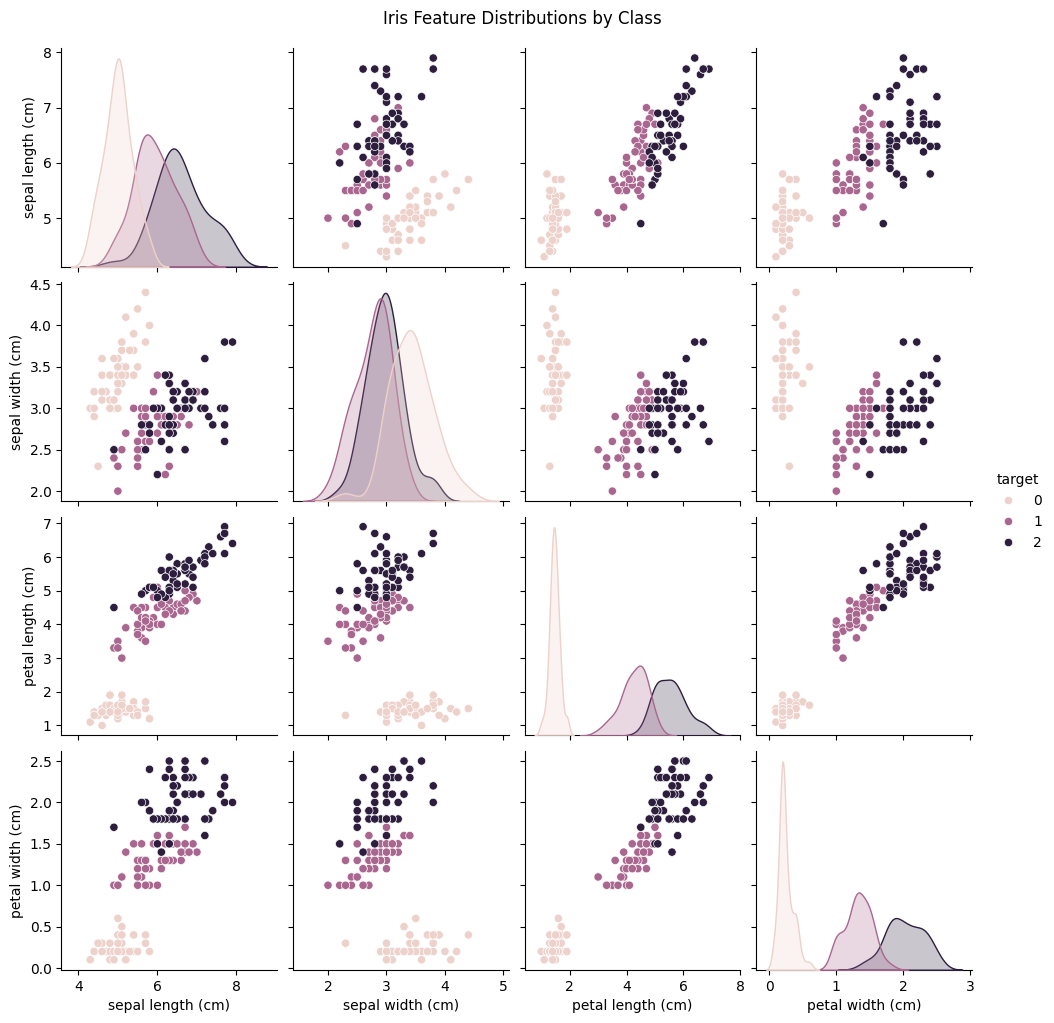

In [26]:
print(df.isnull().sum())

sns.pairplot(df, hue='target')
plt.suptitle('Iris Feature Distributions by Class', y=1.02)
plt.show()

In [27]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Features scaled successfully.")

Features scaled successfully.


In [29]:
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

for k in k_values:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_cv, X_train, y_train, cv=5).mean()
    accuracies.append(score)
    print(f"k={k}, CV Accuracy: {score:.4f}")

k=1, CV Accuracy: 0.9417
k=3, CV Accuracy: 0.9500
k=5, CV Accuracy: 0.9250
k=7, CV Accuracy: 0.9417
k=9, CV Accuracy: 0.9417
k=11, CV Accuracy: 0.9500


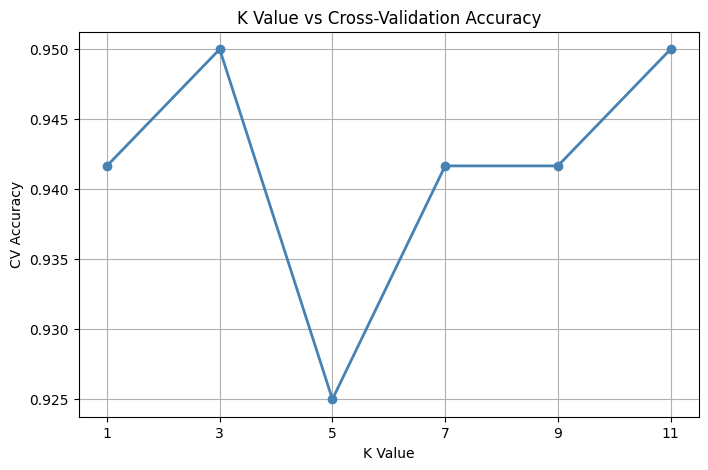

Best K: 3


In [30]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2)
plt.xlabel('K Value')
plt.ylabel('CV Accuracy')
plt.title('K Value vs Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best K: {best_k}")

In [31]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f"Model trained with k={best_k}")

Model trained with k=3


Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1 Score:  1.0

Confusion Matrix:


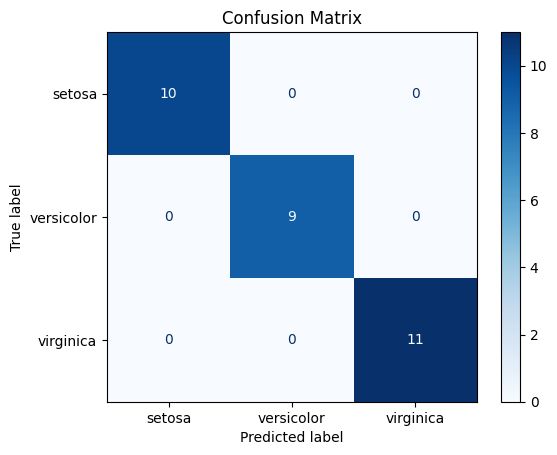

In [32]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:   ", recall_score(y_test, y_pred, average='macro'))
print("F1 Score: ", f1_score(y_test, y_pred, average='macro'))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [33]:
sample = scaler.transform([
    [5.1, 3.5, 1.4, 0.2],   # likely Setosa
    [6.7, 3.0, 5.2, 2.3],   # likely Virginica
    [5.8, 2.7, 4.1, 1.0]    # likely Versicolor
])

predictions = knn.predict(sample)

for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: Predicted class → {data.target_names[pred]}")

Sample 1: Predicted class → setosa
Sample 2: Predicted class → virginica
Sample 3: Predicted class → versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
